In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
import os

from sklearn.linear_model import LassoLars
from sklearn.metrics.pairwise import euclidean_distances
from scipy.stats import chi2

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
path_to_proj = "/content/drive/MyDrive/Master's/Second Year Grad/CV/CV Final Project"

save_dir = os.path.join(path_to_proj, 'code/Final_Implementations/denoising/')
# making save_dir if needed
os.makedirs(save_dir, exist_ok=True)

# Denoising with Non-local Sparse Model

Original papers:
- Model implementation from [Non-local Sparse Models for Image Restoration](https://www.di.ens.fr/~fbach/iccv09_mairal.pdf) (Mairal et al., 2009)
- Initial Dictionary Learning from [Online Dictionary Learning for Sparse Coding](https://www.di.ens.fr/~fbach/mairal_icml09.pdf) (Mairal et al., 2009)

In [ ]:
# HYPERPARAMETERS

# patch hyperparams
patch_size = 8 # e.g. 8x8 patches
stride = 2

# number of dictionary elements to learn
k = 384

# LASSO regularization parameter
l = 0.1

# noise standard deviation assumption
sigma = 10.0

# controls threshold of distance between original and denoised patches
tau = 0.8

Denoising Using the Techniques Described in "Non-local Sparse Models for Image Restoration" (Mairal et al., 2009)

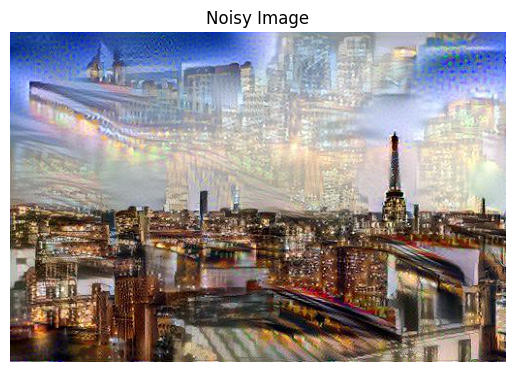

(341, 512, 3)


In [ ]:
input_img = "code/Final_Implementations/results/paris_nyc.jpg"
input_path = os.path.join(path_to_proj, input_img)

# showing initial image
plt.imshow(plt.imread(input_path))
plt.title('Noisy Image')
plt.axis('off')
plt.show()

img = img_to_array(load_img(input_path)) # (height, width, 3)

print(img.shape)

## Creating Initial Dictionary $D_0$

In [ ]:
img = torch.tensor(img)
unfold = torch.nn.Unfold(kernel_size=(patch_size, patch_size), stride=stride)
patches = unfold(img.permute(2,0,1).unsqueeze(0)) # shape (1, 3*patch_size*patch_size, num_patches)
patches = patches.squeeze(0).T # shape (num_patches, 3*patch_size*patch_size)
patches = patches.reshape(-1, 3, patch_size, patch_size) # shape (num_patches, 3, patch_size, patch_size)
patches = patches.permute(0, 2, 3, 1) # shape (num_patches, patch_size, patch_size, 3)

print(patches.shape)

torch.Size([42251, 8, 8, 3])


torch.Size([8, 8, 3])


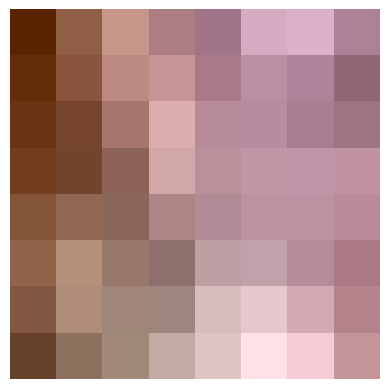

In [ ]:
test = patches[np.random.randint(0, patches.shape[0])]
print(test.shape)
test = array_to_img(test)
plt.imshow(test)
plt.axis('off')
plt.show()

In [ ]:
# normalizing patches (substract and store RGB means)

RGB_means = patches.mean(dim=(1,2))
patches_norm = patches - RGB_means[:, None, None, :]

print(RGB_means.shape)

torch.Size([42251, 3])


In [ ]:
# initialize dictionary (as random gaussian noise)
m = patch_size * patch_size * 3
D_T = np.random.randn(m, k)
D_T /= np.linalg.norm(D_T, axis=0, keepdims=True)  # normalize dim k to have l_2 norm

In [ ]:
# run training loop
num_train_samp = 10000
train_ind = np.random.choice(np.arange(patches.shape[0]),
                             size=min(num_train_samp, patches.shape[0]),
                             replace=False)

px = patches.reshape(patches.shape[0], -1)
m = px.shape[-1]

A, B = np.zeros((k,k)), np.zeros((m, k))

def update_D(D, A, B, n=1):
  # one iteration shown in the paper to be empircally good enough with D_{t-1} warm start
  k = D.shape[1]
  for i in range(n):
    for j in range(k):
      if A[j,j] == 0:
        continue
      u_j = (1/A[j,j])*(B[:,j]-(D@A[:,j])) + D[:,j]
      D[:,j] = 1/(max(1, np.linalg.norm(u_j))) * u_j

  return D

# LARS model for sparse coding
model = LassoLars(alpha=l, fit_intercept=False)

for ind in tqdm(train_ind, desc='Training Image Dictionary'):
  x_t = px[ind]

  # sparse coding -- solve for alpha_t
  model.fit(D_T, x_t)
  alpha_t = model.coef_

  A += np.outer(alpha_t, alpha_t)
  B += np.outer(x_t, alpha_t)

  D_T = update_D(D_T, A, B)

print(D_T.shape)

Training Image Dictionary: 100%|██████████| 10000/10000 [04:58<00:00, 33.51it/s]

(192, 384)


## Running Denoising Algorithm

Finding set of neighboring patches $S_i$

In [ ]:
# find similar patches
y_t = patches_norm.reshape(patches_norm.shape[0], -1) # shape (N, m)
N = y_t.shape[0]

dist = euclidean_distances(y_t, y_t)**2 # shape (N, N)
dist_thres = ((32*sigma)**2) / m

S_t = [np.where(dist[i] <= dist_thres)[0] for i in range(N)]

In [ ]:
print(f"Number of patches with only 1 neighbor: {len([i for i in S_t if len(i) == 1])}")

Number of patches with only 1 neighbor: 42203


In [ ]:
# getting thresholds
def get_epsilon(m, S_i, sigma=sigma, tau=tau):
  df = m * len(S_i)
  F = chi2.ppf(tau, df=df)
  return (sigma**2) * F

epsilons = np.array([get_epsilon(m, S_i) for S_i in S_t])

Adapting Dictionary to image (learning $D$ and $A_i$)

In [ ]:
p, q = 1, 2
constraint_weight = 10.0 # amount to upweigh importance of epsilon constraint
n_iter = 1000

In [ ]:
D = torch.tensor(D_T.copy(), dtype=torch.float32, requires_grad=True)


# initialize all A_i as random noise
A_t = []
for i in range(N):
    S_i = S_t[i]
    A_i = torch.randn((k, len(S_i)), dtype=torch.float32, requires_grad=True)
    A_t.append(A_i)

optimizer = torch.optim.Adam([D] + A_t, lr = 0.001)

In [ ]:
def A_pq_norm(A_i, p=1, q=2):
  '''
  computes ||A||_{p,q}
  '''
  # compute q-norm of each row
  norms = torch.norm(A_i, p=q, dim=1)

  # raise norms to power p and sum over k
  norm = torch.sum(torch.pow(norms, p))
  return norm


for step in tqdm(range(n_iter), desc='Training A_i and D'):
  optimizer.zero_grad()
  total_loss = 0

  for i in range(N):
    S_i = S_t[i]      # shape (|S_i|)
    A_i = A_t[i]      # shape (k, |S_i|)
    y_Si = y_t[S_i].T # shape (m, |S_i|)
    epsilon = epsilons[i]

    # get reconstruction loss
    patch_est = D @ A_i # shape (m, |S_i|)

    # finding squared euclidean distance and summing over all j \in S_i
    recon_loss = torch.sum((y_Si - patch_est) ** 2)
    constraint = F.relu(recon_loss - epsilon)

    Ai_norm_penalty = A_pq_norm(A_i, p=p, q=q) / (len(S_i) ** p)

    total_loss += Ai_norm_penalty + (constraint_weight * constraint)

  total_loss.backward()
  optimizer.step()

  if step % 100 == 0:
    print(f"Step: {step}, Loss: {total_loss.item():.4f}")

Training A_i and D:   0%|          | 1/1000 [00:31<8:37:23, 31.07s/it]

Step: 0, Loss: 55346298880.0000


Training A_i and D:  10%|█         | 101/1000 [44:26<6:22:27, 25.53s/it]

Step: 100, Loss: 49822613504.0000


Training A_i and D:  20%|██        | 201/1000 [1:27:38<5:46:27, 26.02s/it]

...

Training A_i and D:  80%|████████  | 801/1000 [5:49:35<1:26:38, 26.12s/it]

Step: 800, Loss: 7166891520.0000


Training A_i and D:  90%|█████████ | 901/1000 [6:33:36<43:33, 26.40s/it]

Step: 900, Loss: 5184757760.0000


Training A_i and D: 100%|██████████| 1000/1000 [7:17:19<00:00, 26.24s/it]


Denoising with fixed dictionary

In [ ]:
# Note: just need to remove D from optimizer...loss is the same otherwise
# Can use D_T immediately instad of training new D

Creating denoised patch estimates:

Final patch estimate is average of estimates for all the neighboring patch sets to which it belongs.

In [ ]:
patches_denoised = np.zeros_like(y_t)
patch_counts = np.zeros(N) # count number of overlapping patch estimates

for i in tqdm(range(N), desc='denoised patch estimates'):
  A_i = A_t[i]
  S_i = S_t[i]

  patch_estimates = D @ A_i # shape (m, |S_i|)

  for idx, j in enumerate(S_i):
    patches_denoised[j] += patch_estimates[:, idx].cpu().detach().numpy()
    patch_counts[j] += 1

# average over patch estimates
patch_counts[patch_counts == 0] = 1
patches_denoised /= patch_counts[:, None]

patches_denoised = torch.tensor(patches_denoised)

# adding back RGB mean
patches_final = patches_denoised.reshape(N, patch_size, patch_size, 3)
patches_final += RGB_means[:, None, None, :]

denoised patch estimates: 100%|██████████| 42251/42251 [00:01<00:00, 23835.17it/s]


## Reconstructing denoised image from patches

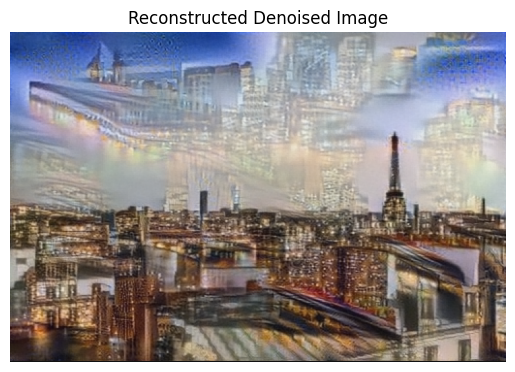

In [ ]:
# reconstruct from patches
def reconstruct_from_patches(patches, img):
  H, W, C = img.shape

  if len(patches.shape) != 4:
    # expanding out flattened patches
    patches = patches.reshape(-1, patch_size, patch_size, 3)

  # reshape patches for fold
  num_patches = patches.shape[0]
  patches_reshape = patches.permute(0, 3, 1, 2) # (num_patches, C, patch_size, patch_size)
  patches_reshape = patches_reshape.reshape(num_patches, -1).transpose(0, 1).unsqueeze(0) # (1, num_patches, C x patch_size x patch_size)

  # store overlaps
  ones = torch.ones_like(patches)
  ones_reshape = ones.permute(0, 3, 1, 2).reshape(ones.shape[0], -1).transpose(0, 1).unsqueeze(0)

  fold = torch.nn.Fold(output_size=(H,W), kernel_size=(patch_size, patch_size), stride=stride)

  img_reconstructed = fold(patches_reshape).squeeze(0).permute(1,2,0)
  overlap_count = fold(ones_reshape).squeeze(0).permute(1,2,0)
  overlap_count[overlap_count == 0] = 1

  img_norm = img_reconstructed / overlap_count

  return img_norm.detach().numpy()

img_reconstructed = reconstruct_from_patches(patches_final, img)

plt.imshow(array_to_img(img_reconstructed))
plt.title('Reconstructed Denoised Image')
plt.axis('off')
plt.show()

In [ ]:
# save image
img_name = input_img.split('/')[-1].replace('.jpg', '_NLSparse.jpg')
save_path = os.path.join(save_dir, f"denoised_{img_name}")
array_to_img(img_reconstructed).save(save_path)
print(f"Denoising complete! Image saved as 'denoised_{img_name}'")

Style transfer complete! Image saved as 'denoised_paris_nyc_opt.jpg'


#Compare with Pre-packaged Non-Local Means (different from Non-Local Sparse Model)

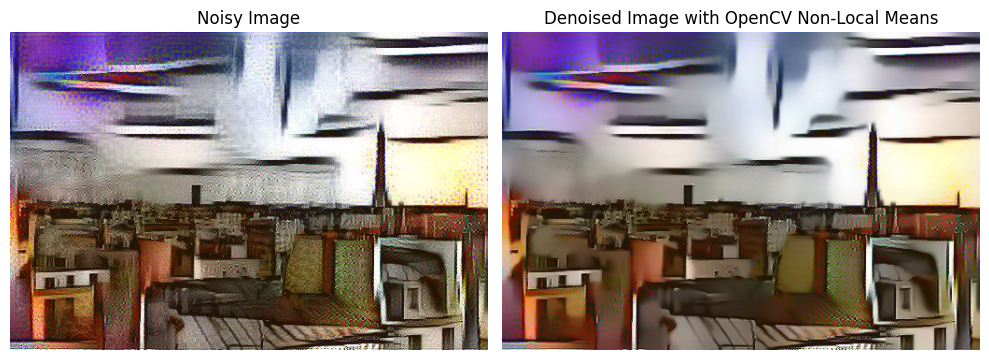

In [3]:
import cv2

input_img = "code/result/modern_v2/paris_mondrian_CW1000.0_SW1.jpg"
input_path = os.path.join(path_to_proj, input_img)
img = plt.imread(input_path)

# TESTING OpenCV NLM RESULT
denoised_nlm = cv2.fastNlMeansDenoisingColored(cv2.imread(input_path), h=15, templateWindowSize=7, searchWindowSize=21)

# Convert BGR to RGB
denoised_rgb = cv2.cvtColor(denoised_nlm, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(array_to_img(denoised_rgb))
plt.title('Denoised Image with OpenCV Non-Local Means')
plt.axis('off')
plt.tight_layout()
plt.show()

###Implementing Non-Local Means

from paper, denoised pixel is
$x[i] = \sum_{j=1}^n\frac{K_h (y_i - y_j)}{\sum_{l=1}^n K_h (y_i - y_l)}y[j]$

Because the implementation is based in NumPy, we use Numba to speed up operations ([Grayscale Reference](https://github.com/antimattercorrade/Image_Denoising/blob/main/Image_Denoising.ipynb); [OpenCV Color NLM Source Code](https://github.com/stonier/opencv2/blob/master/modules/photo/src/denoising.cpp))

- approx 11 min per channel without Numba
- approx 50 sec per channel with Numba

In [21]:
from numba import jit

# Gaussian kernel
@jit(nopython = True, cache = True)
def K(y_i, y_j, h):
  u = (np.linalg.norm(y_i-y_j)**2)/ h
  return np.exp(-u)

# denoised pixel x[i]
@jit(nopython = True, cache = True)
def get_x_i(y_i, neighbors, h):
  total = []
  num = 0

  # iterating from j=1 to n (neighboring pixels)
  for i in range(neighbors.shape[0]):
    for j in range(neighbors.shape[1]):
      y_j = neighbors[i,j]

      # get center pixel y_j
      center_x, center_y = y_j.shape[0]//2, y_j.shape[1]//2
      center_j = y_j[center_x, center_y]

      # compute K(y_i - y_j)
      K_yi_yj = K(y_i, y_j, h)
      total.append(K_yi_yj)
      num += K_yi_yj * center_j

  return np.array([num/sum(total)])

# create patches centered at each pixel
@jit(nopython = True, cache = True)
def get_patches(img_pad, patch_size, patch_width, H, W):
  # matrix where each index [i,j] holds patch of shape (patch_size x patch_size)
  patches = np.zeros((H, W, patch_size, patch_size))

  for i in range(H):
    for j in range(W):
      # extract patches
      i_pad, j_pad = i+patch_width, j+patch_width
      patches[i,j] = img_pad[(i_pad-patch_width):(i_pad+patch_width+1),
                             (j_pad-patch_width):(j_pad+patch_width+1)]
  return patches

# getting denoised pixel i,j
@jit(nopython = True, cache = True)
def NLM_pixel(patches, search_width, i, j, h):
  # get patch at the center of search window (y_i)
  y_i = patches[i, j]

  # get all other patches in search window
  H, W = patches.shape[0], patches.shape[1]
  i_min = np.maximum(i-search_width, 0)
  i_max = np.minimum(i+search_width+1, H)
  j_min = np.maximum(j-search_width, 0)
  j_max = np.minimum(j+search_width+1, W)
  neighbors = patches[i_min:i_max,j_min:j_max]

  # denoised pixel
  x_i = get_x_i(y_i, neighbors, h)

  # clip pixel
  return np.clip(x_i, 0.0, 255.0)[0]

# single channel non-local means
def NLM_grayscale(img, h, patch_size=7, search_size=21):
  denoised_img = np.zeros(img.shape)
  H, W = img.shape

  # get search_width, patch_width
  search_width = search_size//2
  patch_width = patch_size//2

  # pad image for patches
  img_pad = np.pad(img, patch_width, mode='reflect')

  # scale h by patch area (patch_size x patch_size)
  h = (h**2) * (patch_size**2)

  # get all patches
  patches = get_patches(img_pad, patch_size, patch_width, H, W)

  # run NLM on all image pixels
  for i in tqdm(range(H), desc='denoising pixels'):
    for j in range(W):
      denoised_img[i, j] = NLM_pixel(patches, search_width, i, j, h)

  return denoised_img

# multi channel non-local means
def NLM_color(img, h, patch_size=7, search_size=21):
  img_lab = cv2.cvtColor((img).astype(np.uint8), cv2.COLOR_RGB2Lab).astype(np.float32)
  img_l, img_a, img_b = cv2.split(img_lab)

  denoised_l = NLM_grayscale(img_l, h, patch_size, search_size)
  denoised_a = NLM_grayscale(img_a, h, patch_size, search_size)
  denoised_b = NLM_grayscale(img_b, h, patch_size, search_size)

  denoised_lab = cv2.merge((denoised_l, denoised_a, denoised_b))
  denoised_rgb = cv2.cvtColor(denoised_lab.astype(np.uint8), cv2.COLOR_Lab2RGB)

  return denoised_rgb

denoising pixels: 100%|██████████| 341/341 [00:51<00:00,  6.56it/s]


Denoising complete! Image saved as 'denoised_paris_mondrian_CW1000.0_SW1_NLMeans.jpg'


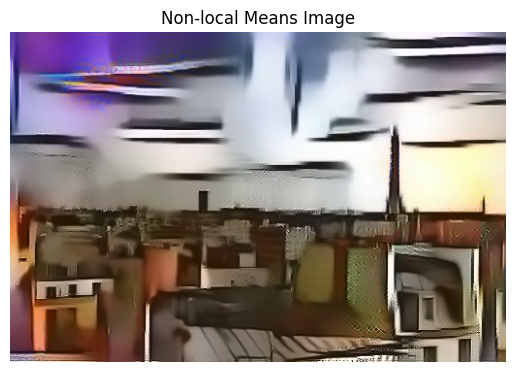

In [22]:
plt.imshow(NLM_color(img, h=20))
plt.title('Non-local Means Image')
plt.axis('off')

# save figure
img_name = input_img.split('/')[-1].replace('.jpg', '_NLMeans.jpg')
plt.savefig(os.path.join(save_dir, f"denoised_{img_name}"))
print(f"Denoising complete! Image saved as 'denoised_{img_name}'")

plt.show()

## OpenCV Denoising

**Gaussian:**
Blurs both content and style equally, loosing edges

**Bilateral:**
Edges and image structure are maintained even under strong filtering

Denoising complete! Image saved as 'denoised_paris_mondrian_CW1000.0_SW1_OpenCV.jpg'


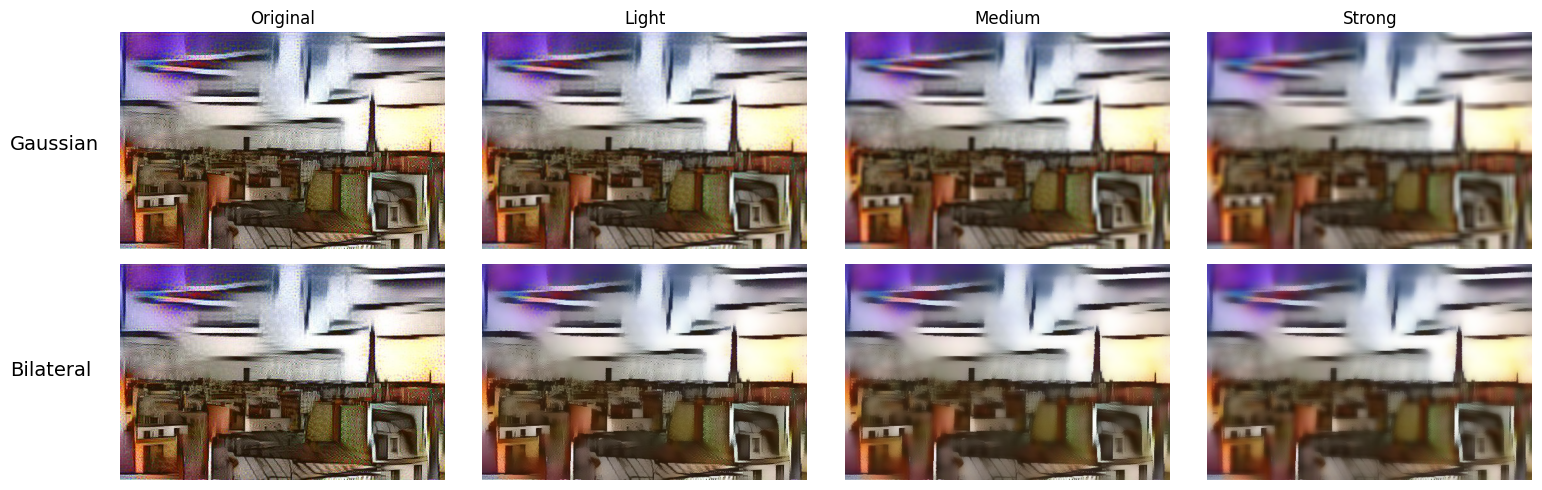

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(input_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Gaussian filters
gaussian_light = cv2.GaussianBlur(img, (5, 5), sigmaX=1.0)
gaussian_medium = cv2.GaussianBlur(img, (7, 7), sigmaX=3.0)
gaussian_strong = cv2.GaussianBlur(img, (11, 11), sigmaX=5.0)

# Bilateral filters
bilateral_light = cv2.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)
bilateral_medium = cv2.bilateralFilter(img, d=15, sigmaColor=150, sigmaSpace=150)
bilateral_strong = cv2.bilateralFilter(img, d=15, sigmaColor=250, sigmaSpace=250)

# Median filters
#median_light = cv2.medianBlur(img, ksize=3)
#median_medium = cv2.medianBlur(img, ksize=5)
#median_strong = cv2.medianBlur(img, ksize=7)

filters = ["Original", "Light", "Medium", "Strong"]
rows = [
    ("Gaussian", [img, gaussian_light, gaussian_medium, gaussian_strong]),
    ("Bilateral", [img, bilateral_light, bilateral_medium, bilateral_strong]),
    #("Median", [img, median_light, median_medium, median_strong])
]

fig, axes = plt.subplots(len(rows), 4, figsize=(16, 5))

for row_idx, (filter_name, images) in enumerate(rows):
    for col_idx in range(4):
        ax = axes[row_idx, col_idx]
        ax.imshow(images[col_idx])
        if row_idx == 0:
            ax.set_title(filters[col_idx], fontsize=12)
        ax.axis("off")

fig.text(0.03, 0.7, "Gaussian", fontsize=14, va='center', ha='left')
fig.text(0.03, 0.25, "Bilateral", fontsize=14, va='center', ha='left')
#fig.text(0.03, 0.22, "Median", fontsize=14, va='center', ha='left')

# save figure
img_name = input_img.split('/')[-1].replace('.jpg', '_OpenCV.jpg')
plt.savefig(os.path.join(save_dir, f"denoised_{img_name}"))
print(f"Denoising complete! Image saved as 'denoised_{img_name}'")

plt.tight_layout(rect=[0.08, 0, 1, 1])
plt.show()